# ✈️ Lab 32: Detecting Anomalies in Transaction Logs

## 📘 Lab Overview
In this lab, you will learn how to detect suspicious financial transactions using statistical anomaly detection techniques in Python. You will generate a realistic transaction log dataset, load it into pandas, explore transaction behavior, calculate anomaly thresholds using both IQR and z-scores, flag high-risk transactions, visualize suspicious patterns, validate your results, and export your findings.

## 🎯 Objectives
By the end of this lab, students will be able to:
* Load and analyze transaction log data from CSV files using Python
* Calculate statistical measures including Interquartile Range (IQR) and z-scores for numeric features
* Identify and flag high-risk transactions based on statistical thresholds
* Apply anomaly detection techniques to real-world financial-style data
* Understand the importance of transaction monitoring in fraud prevention
* Create visualizations to better understand transaction patterns and anomalies
* Save anomaly detection reports and validate analysis outputs

## 🧰 Prerequisites
Before starting this lab, students should have:
* Basic understanding of Python programming concepts
* Familiarity with data structures like lists and dictionaries
* Basic knowledge of statistics such as mean, standard deviation, and quartiles
* Understanding of CSV file format
* Basic familiarity with notebook-based Python workflows

## ⚙️ Colab Environment Setup
This lab is designed to run fully inside **Google Colab**. We will start by installing and importing the necessary libraries for data manipulation, statistics, and visualization.

In [1]:
# Install necessary libraries if they are not already available
!pip install pandas numpy matplotlib seaborn scipy

import os
import random
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ignore warnings for cleaner output
warnings.filterwarnings("ignore")

# Set plot styling for professional-looking charts
plt.style.use("default")
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


## 🧠 What You Are Going to Do

In simple words, this lab teaches you how to find “unusual” transactions in a big list of financial records.

**ELI10 Explanation:** Imagine you usually spend $20 on lunch. If suddenly there is a charge for $5,000 at 3:00 AM in a different city, that is an **anomaly**. We use math (statistics) to help the computer spot these weird patterns automatically so humans don't have to look through millions of lines of data.

---

## 🧪 Creating the Transaction Dataset
Before we can detect anomalies, we need data. We will generate a synthetic dataset that mimics real-world bank transactions, including a small number of intentional "suspicious" entries.

In [2]:
# Set random seed for reproducibility so everyone gets the same results
np.random.seed(42)
random.seed(42)

def generate_transaction_data(num_transactions=1000):
    """
    Generate a realistic transaction dataset with mostly normal transactions
    and a small percentage of anomalous transactions.
    """
    data = []
    base_time = datetime.now()

    normal_categories = ['grocery', 'gas', 'restaurant', 'retail', 'online']
    anomaly_categories = ['jewelry', 'electronics', 'luxury']
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
    tx_types = ['purchase', 'withdrawal', 'transfer']

    # 95% normal transactions
    normal_count = int(num_transactions * 0.95)
    anomaly_count = num_transactions - normal_count

    for i in range(normal_count):
        timestamp = base_time - timedelta(
            days=random.randint(0, 30),
            hours=random.randint(0, 23),
            minutes=random.randint(0, 59)
        )

        # Normal transactions follow a normal distribution around $150
        amount = round(np.random.normal(150, 75), 2)
        if amount < 0: amount = abs(amount)

        transaction = {
            'transaction_id': f'TXN_{i+1:06d}',
            'user_id': f'USER_{random.randint(1, 200):04d}',
            'amount': amount,
            'timestamp': timestamp,
            'merchant_category': random.choice(normal_categories),
            'location': random.choice(cities),
            'transaction_type': random.choice(tx_types)
        }
        data.append(transaction)

    # 5% anomalous transactions (High amounts, weird times, or frequent hits)
    for i in range(anomaly_count):
        anomaly_type = random.choice(['high_amount', 'unusual_time', 'frequent_transactions'])

        if anomaly_type == 'high_amount':
            timestamp = base_time - timedelta(days=random.randint(0, 30), hours=random.randint(8, 22))
            amount = round(np.random.uniform(2000, 10000), 2)
            merchant_category = random.choice(anomaly_categories)
            transaction_type = 'purchase'

        elif anomaly_type == 'unusual_time':
            # Suspicious late-night transactions
            timestamp = base_time - timedelta(days=random.randint(0, 30), hours=random.randint(0, 3))
            amount = round(np.random.uniform(300, 2500), 2)
            merchant_category = random.choice(['online', 'electronics', 'luxury'])
            transaction_type = random.choice(tx_types)

        else:  # frequent_transactions
            suspicious_user = f'USER_{random.randint(1, 20):04d}'
            timestamp = base_time - timedelta(days=random.randint(0, 7), hours=random.randint(6, 23))
            amount = round(np.random.uniform(400, 3000), 2)
            merchant_category = random.choice(['online', 'retail', 'electronics'])
            transaction_type = random.choice(tx_types)

            transaction = {
                'transaction_id': f'TXN_{normal_count + i + 1:06d}',
                'user_id': suspicious_user,
                'amount': amount,
                'timestamp': timestamp,
                'merchant_category': merchant_category,
                'location': random.choice(cities),
                'transaction_type': transaction_type
            }
            data.append(transaction)
            continue

        transaction = {
            'transaction_id': f'TXN_{normal_count + i + 1:06d}',
            'user_id': f'USER_{random.randint(1, 200):04d}',
            'amount': amount,
            'timestamp': timestamp,
            'merchant_category': merchant_category,
            'location': random.choice(cities),
            'transaction_type': transaction_type
        }
        data.append(transaction)

    return data

print("Generating transaction data...")
transactions = generate_transaction_data(1000)
df_generated = pd.DataFrame(transactions)

# Save to CSV for the lab requirements
df_generated.to_csv('transaction_logs.csv', index=False)
print(f"Generated {len(df_generated)} transactions and saved to 'transaction_logs.csv'")
display(df_generated.head())

Generating transaction data...
Generated 1000 transactions and saved to 'transaction_logs.csv'


,transaction_id,user_id,amount,timestamp,merchant_category,location,transaction_type
0,TXN_000001,USER_0190,187.25,2026-03-28 13:11:35.636199,restaurant,Los Angeles,purchase
1,TXN_000002,USER_0174,139.63,2026-04-12 17:06:35.636199,online,New York,transfer
2,TXN_000003,USER_0024,198.58,2026-04-04 15:11:35.636199,gas,Los Angeles,transfer
3,TXN_000004,USER_0051,264.23,2026-03-29 15:37:35.636199,online,Houston,purchase
4,TXN_000005,USER_0002,132.44,2026-04-02 21:55:35.636199,gas,Houston,withdrawal


## 🔍 Loading and Exploring the Data

Now that we have a file, we will build a professional `TransactionAnomalyDetector` class.

**Why use a class?** Encapsulating our code in a class makes it reusable, organized, and professional. It allows us to keep the data and the detection methods in one place.

In [3]:
class TransactionAnomalyDetector:
    def __init__(self, csv_file):
        """Initialize the detector and load data immediately."""
        self.df = None
        self.load_data(csv_file)

    def load_data(self, csv_file):
        """Load transaction data from CSV and fix data types."""
        try:
            print(f"Loading data from {csv_file}...")
            self.df = pd.read_csv(csv_file)
            # Convert strings to actual datetime objects for time-based analysis
            self.df['timestamp'] = pd.to_datetime(self.df['timestamp'], errors='coerce')
            print(f"Successfully loaded {len(self.df)} transactions.")
        except Exception as e:
            print(f"Error loading data: {e}")

    def explore_data(self):
        """Calculate and display basic statistics to understand 'normal' behavior."""
        print("\n" + "=" * 50)
        print("TRANSACTION DATA EXPLORATION")
        print("=" * 50)

        # Amount statistics help us see the range of spending
        stats_summary = self.df.describe(include='all')
        print(f"Unique users: {self.df['user_id'].nunique()}")
        print(f"Mean amount: ${self.df['amount'].mean():.2f}")
        print(f"Max amount: ${self.df['amount'].max():.2f}")

        return stats_summary

# Initialize our detector object
detector = TransactionAnomalyDetector('transaction_logs.csv')
detector.explore_data()

Loading data from transaction_logs.csv...
Successfully loaded 1000 transactions.

TRANSACTION DATA EXPLORATION
Unique users: 197
Mean amount: $270.35
Max amount: $9745.55


,transaction_id,user_id,amount,timestamp,merchant_category,location,transaction_type
count,1000,1000,1000.000000,1000,1000,1000,1000
unique,1000,197,NaN,NaN,8,5,3
top,TXN_001000,USER_0170,NaN,NaN,retail,Los Angeles,purchase
freq,1,13,NaN,NaN,201,210,349
mean,NaN,NaN,270.346700,2026-04-02 01:32:56.876198656,NaN,NaN,NaN
min,NaN,NaN,0.930000,2026-03-17 16:22:35.636199,NaN,NaN,NaN
25%,NaN,NaN,104.972500,2026-03-25 10:59:50.636198912,NaN,NaN,NaN
50%,NaN,NaN,155.970000,2026-04-02 05:14:05.636198912,NaN,NaN,NaN
75%,NaN,NaN,207.622500,2026-04-09 13:35:05.636198912,NaN,NaN,NaN
max,NaN,NaN,9745.550000,2026-04-17 14:57:35.636199,NaN,NaN,NaN


## 📦 IQR-Based Anomaly Detection

**ELI10 Explanation:** IQR (Interquartile Range) looks at the "middle half" of your data. We draw a box around the typical spending. Anything that falls way outside the box (usually 1.5 times the size of the box) is considered an outlier.

**Why it matters:** It is robust to extreme values, meaning it won't be easily fooled by a few large numbers when defining what is "normal."


IQR ANOMALY DETECTION FOR AMOUNT
IQR: $102.65 | Bounds: $-49.00 to $361.60
Anomalies found: 51 (5.10%)


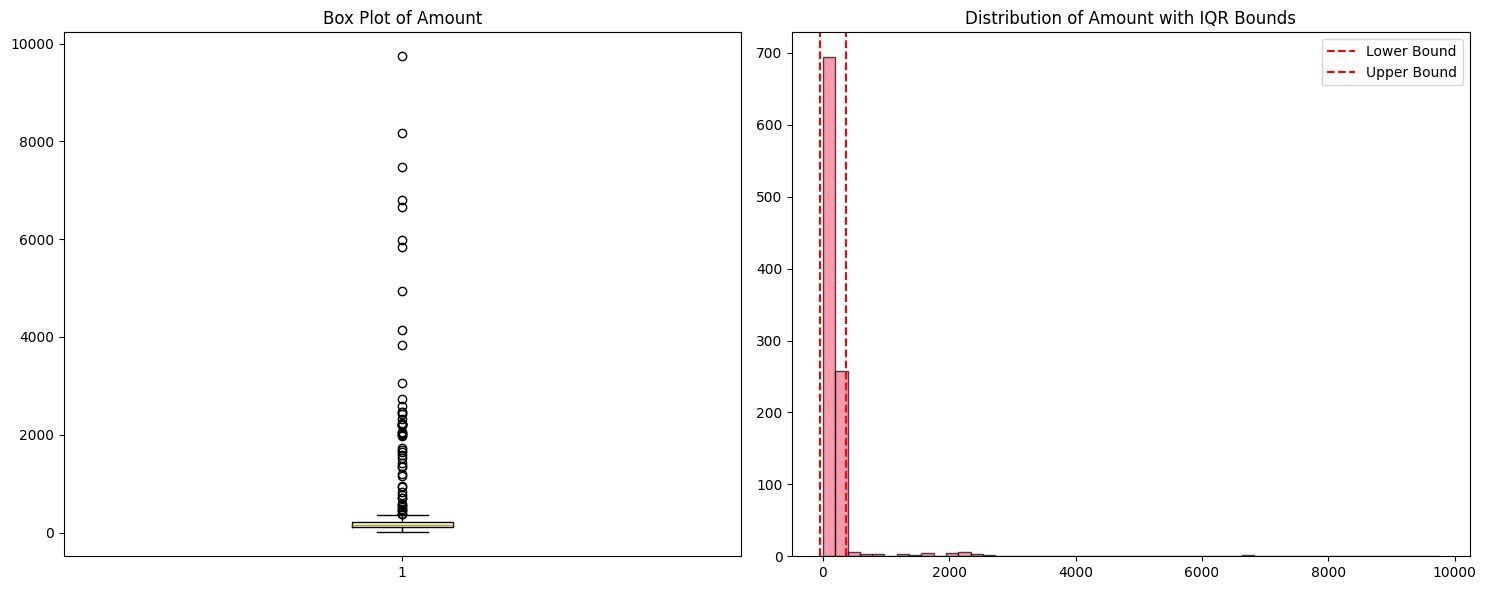

,transaction_id,user_id,amount,timestamp,merchant_category,location,transaction_type,iqr_anomaly
209,TXN_000210,USER_0078,438.95,2026-04-13 15:10:35.636199,retail,New York,purchase,True
478,TXN_000479,USER_0019,380.92,2026-04-08 08:27:35.636199,grocery,Chicago,purchase,True
950,TXN_000951,USER_0009,2724.66,2026-04-12 17:12:35.636199,retail,Los Angeles,withdrawal,True
951,TXN_000952,USER_0029,3839.64,2026-04-12 06:12:35.636199,electronics,Houston,purchase,True
952,TXN_000953,USER_0015,954.07,2026-04-12 19:12:35.636199,online,New York,withdrawal,True
953,TXN_000954,USER_0048,2249.07,2026-04-16 00:12:35.636199,jewelry,New York,purchase,True
954,TXN_000955,USER_0187,1733.67,2026-04-09 15:12:35.636199,luxury,New York,withdrawal,True
955,TXN_000956,USER_0127,4948.21,2026-04-15 06:12:35.636199,jewelry,Los Angeles,purchase,True
956,TXN_000957,USER_0119,2201.59,2026-04-04 14:12:35.636199,electronics,New York,withdrawal,True
957,TXN_000958,USER_0199,1341.06,2026-04-15 15:12:35.636199,online,Houston,withdrawal,True


In [4]:
def calculate_iqr_anomalies(self, column='amount', multiplier=1.5):
    """Calculate IQR and flag outliers based on the 'multiplier' threshold."""
    print("\n" + "=" * 50)
    print(f"IQR ANOMALY DETECTION FOR {column.upper()}")
    print("=" * 50)

    Q1 = self.df[column].quantile(0.25)
    Q3 = self.df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)

    print(f"IQR: ${IQR:.2f} | Bounds: ${lower_bound:.2f} to ${upper_bound:.2f}")

    # Identify rows where the amount is outside these bounds
    self.df['iqr_anomaly'] = (self.df[column] < lower_bound) | (self.df[column] > upper_bound)
    anomalies = self.df[self.df['iqr_anomaly']].copy()

    print(f"Anomalies found: {len(anomalies)} ({len(anomalies)/len(self.df)*100:.2f}%)")
    self.visualize_iqr_anomalies(column, Q1, Q3, lower_bound, upper_bound)
    return anomalies

def visualize_iqr_anomalies(self, column, Q1, Q3, lower_bound, upper_bound):
    """Visualize the boxplot and histogram for IQR analysis."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Boxplot shows the median and the whiskers (bounds)
    ax1.boxplot(self.df[column], vert=True)
    ax1.set_title(f'Box Plot of {column.title()}')

    # Histogram shows the shape of the data and where our limits are
    ax2.hist(self.df[column], bins=50, alpha=0.7, edgecolor='black')
    ax2.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    ax2.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
    ax2.set_title(f'Distribution of {column.title()} with IQR Bounds')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'iqr_anomalies_{column}.png', dpi=300)
    plt.show()

# Dynamically add methods to our class and run it
TransactionAnomalyDetector.calculate_iqr_anomalies = calculate_iqr_anomalies
TransactionAnomalyDetector.visualize_iqr_anomalies = visualize_iqr_anomalies
detector.calculate_iqr_anomalies('amount')

## 📊 Z-Score-Based Anomaly Detection

**ELI10 Explanation:** A Z-score tells us how many "standard deviations" a value is from the average. If the average is $100 and most people are within $10 of that, a $1,000 transaction has a very high Z-score.

**Why it matters:** It is a standard statistical measure used across many industries to determine how "rare" an event is compared to the mean.


Z-SCORE ANOMALY DETECTION FOR AMOUNT
Anomalies found: 28 (2.80%)


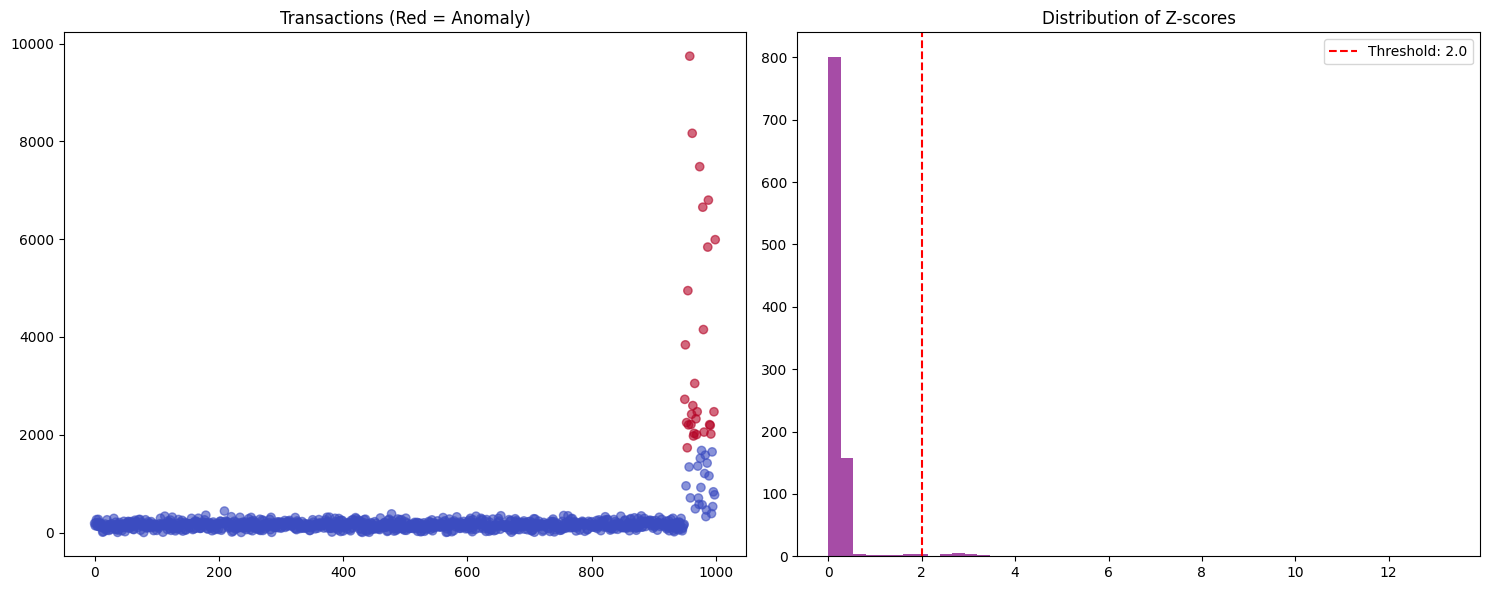

,transaction_id,user_id,amount,timestamp,merchant_category,location,transaction_type,iqr_anomaly,amount_zscore,zscore_anomaly
950,TXN_000951,USER_0009,2724.66,2026-04-12 17:12:35.636199,retail,Los Angeles,withdrawal,True,3.442576,True
951,TXN_000952,USER_0029,3839.64,2026-04-12 06:12:35.636199,electronics,Houston,purchase,True,5.006518,True
953,TXN_000954,USER_0048,2249.07,2026-04-16 00:12:35.636199,jewelry,New York,purchase,True,2.775483,True
954,TXN_000955,USER_0187,1733.67,2026-04-09 15:12:35.636199,luxury,New York,withdrawal,True,2.052551,True
955,TXN_000956,USER_0127,4948.21,2026-04-15 06:12:35.636199,jewelry,Los Angeles,purchase,True,6.561469,True
956,TXN_000957,USER_0119,2201.59,2026-04-04 14:12:35.636199,electronics,New York,withdrawal,True,2.708885,True
958,TXN_000959,USER_0050,9745.55,2026-03-31 01:12:35.636199,jewelry,Chicago,purchase,True,13.290524,True
960,TXN_000961,USER_0189,2210.97,2026-04-10 16:12:35.636199,online,New York,withdrawal,True,2.722042,True
961,TXN_000962,USER_0007,2419.15,2026-04-09 22:12:35.636199,electronics,Chicago,withdrawal,True,3.014048,True
962,TXN_000963,USER_0191,8167.37,2026-03-27 21:12:35.636199,jewelry,Phoenix,purchase,True,11.076868,True


In [5]:
def calculate_zscore_anomalies(self, column='amount', threshold=2.5):
    """Flag anomalies where the z-score exceeds the threshold."""
    print("\n" + "=" * 50)
    print(f"Z-SCORE ANOMALY DETECTION FOR {column.upper()}")
    print("=" * 50)

    mean_val = self.df[column].mean()
    std_val = self.df[column].std()

    # Formula for Z-score: (Value - Mean) / Standard Deviation
    self.df[f'{column}_zscore'] = np.abs((self.df[column] - mean_val) / std_val)
    self.df['zscore_anomaly'] = self.df[f'{column}_zscore'] > threshold

    anomalies = self.df[self.df['zscore_anomaly']].copy()
    print(f"Anomalies found: {len(anomalies)} ({len(anomalies)/len(self.df)*100:.2f}%)")

    self.visualize_zscore_anomalies(column, threshold)
    return anomalies

def visualize_zscore_anomalies(self, column, threshold):
    """Scatter plot and Z-score distribution chart."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Scatter plot shows individual points colored by anomaly status
    ax1.scatter(self.df.index, self.df[column], c=self.df['zscore_anomaly'], cmap='coolwarm', alpha=0.6)
    ax1.set_title('Transactions (Red = Anomaly)')

    # Histogram of the Z-scores themselves
    ax2.hist(self.df[f'{column}_zscore'], bins=50, alpha=0.7, color='purple')
    ax2.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold}')
    ax2.set_title('Distribution of Z-scores')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'zscore_anomalies_{column}.png', dpi=300)
    plt.show()

# Attach and run
TransactionAnomalyDetector.calculate_zscore_anomalies = calculate_zscore_anomalies
TransactionAnomalyDetector.visualize_zscore_anomalies = visualize_zscore_anomalies
detector.calculate_zscore_anomalies('amount', threshold=2.0)

## 🚨 High-Risk Transaction Flagging

Now we combine our methods. We create a **Risk Score**. If a transaction is flagged by both IQR and Z-score, it is extremely high risk. We also add a simple "High Amount" check for any transaction over a specific dollar amount.


HIGH-RISK TRANSACTION FLAGGING
Total high-risk transactions for review: 51


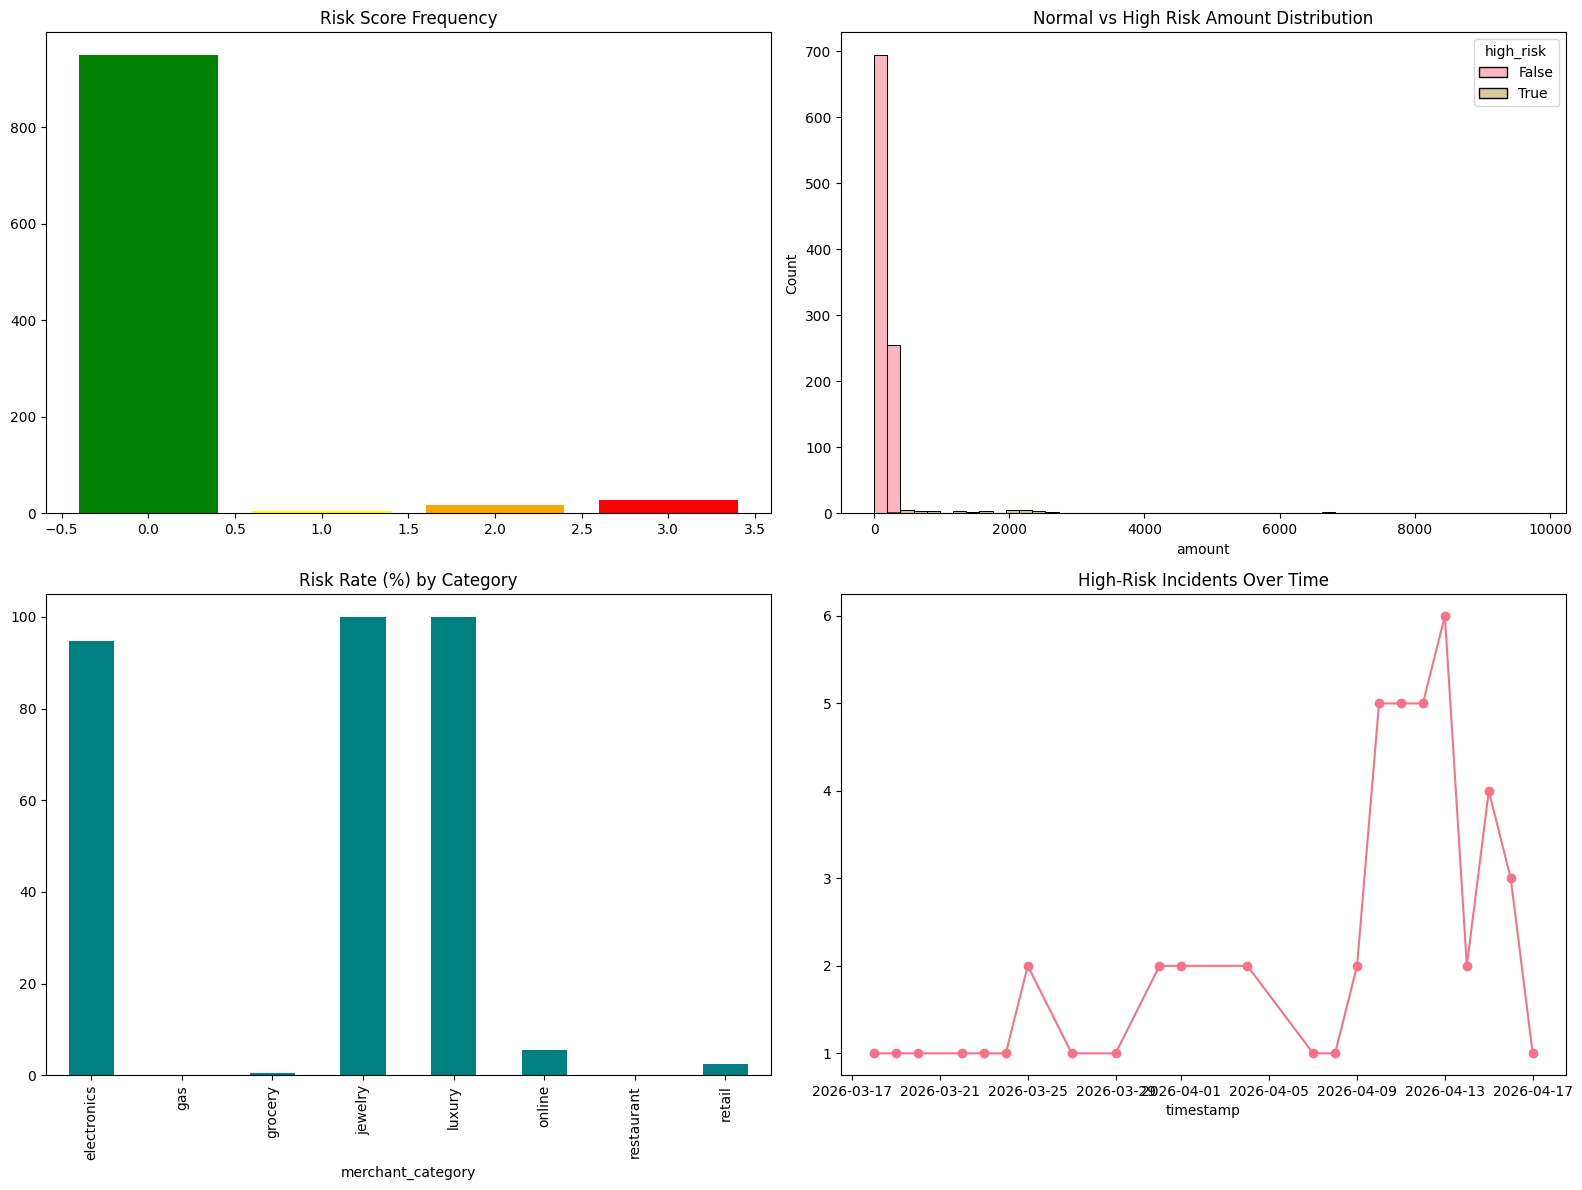

In [6]:
def flag_high_risk_transactions(self, amount_threshold=500):
    """Combine multiple indicators to determine overall risk."""
    print("\n" + "=" * 60)
    print("HIGH-RISK TRANSACTION FLAGGING")
    print("=" * 60)

    self.df['high_amount_risk'] = self.df['amount'] > amount_threshold

    # Calculate Risk Score (0 to 3 based on how many methods flagged it)
    self.df['risk_score'] = (
        self.df['high_amount_risk'].astype(int) +
        self.df['iqr_anomaly'].astype(int) +
        self.df['zscore_anomaly'].astype(int)
    )

    # Any positive risk score flags the transaction as high_risk for review
    self.df['high_risk'] = self.df['risk_score'] > 0

    high_risk_df = self.df[self.df['high_risk']].copy()
    print(f"Total high-risk transactions for review: {len(high_risk_df)}")

    self.visualize_risk_assessment()
    return high_risk_df

def visualize_risk_assessment(self):
    """Generate a dashboard showing risk distribution across the dataset."""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Risk Score Distribution
    risk_counts = self.df['risk_score'].value_counts().sort_index()
    ax1.bar(risk_counts.index, risk_counts.values, color=['green', 'yellow', 'orange', 'red'][:len(risk_counts)])
    ax1.set_title('Risk Score Frequency')

    # 2. Amount: Normal vs Risk
    sns.histplot(data=self.df, x='amount', hue='high_risk', ax=ax2, bins=50)
    ax2.set_title('Normal vs High Risk Amount Distribution')

    # 3. Risk Rate by Category
    risk_rate = self.df.groupby('merchant_category')['high_risk'].mean() * 100
    risk_rate.plot(kind='bar', ax=ax3, color='teal')
    ax3.set_title('Risk Rate (%) by Category')

    # 4. Timeline of Risk
    daily_risk = self.df[self.df['high_risk']].groupby(self.df['timestamp'].dt.date).size()
    daily_risk.plot(ax=ax4, marker='o')
    ax4.set_title('High-Risk Incidents Over Time')

    plt.tight_layout()
    plt.savefig('risk_assessment_dashboard.png', dpi=300)
    plt.show()

# Attach and run
TransactionAnomalyDetector.flag_high_risk_transactions = flag_high_risk_transactions
TransactionAnomalyDetector.visualize_risk_assessment = visualize_risk_assessment
high_risk_transactions = detector.flag_high_risk_transactions()

## 📈 Final Summary and Reporting

In the final step, we export our findings to CSV files. This is how real-world data scientists hand off "to-do lists" to fraud investigators.

In [7]:
def generate_summary_report(self):
    """Print a text summary and export final CSV files."""
    print("\n" + "=" * 60)
    print("ANOMALY DETECTION SUMMARY REPORT")
    print("=" * 60)

    # Export reports
    self.df.to_csv('anomaly_detection_report.csv', index=False)
    high_risk_only = self.df[self.df['high_risk']]
    high_risk_only.to_csv('high_risk_transactions.csv', index=False)

    print(f"Analyzed {len(self.df)} transactions.")
    print(f"Identified {len(high_risk_only)} high-risk transactions.")
    print("Files saved: anomaly_detection_report.csv, high_risk_transactions.csv")

TransactionAnomalyDetector.generate_summary_report = generate_summary_report
detector.generate_summary_report()


ANOMALY DETECTION SUMMARY REPORT
Analyzed 1000 transactions.
Identified 51 high-risk transactions.
Files saved: anomaly_detection_report.csv, high_risk_transactions.csv


## ✅ Validation and Verification

Let's verify our work by checking if the files exist and running a quick validation script.

In [8]:
print("VALIDATION CHECKLIST")
files_to_check = [
    'transaction_logs.csv', 'anomaly_detection_report.csv', 'high_risk_transactions.csv',
    'iqr_anomalies_amount.png', 'zscore_anomalies_amount.png', 'risk_assessment_dashboard.png'
]

for f in files_to_check:
    print(f"- {f}: {'[OK]' if os.path.exists(f) else '[MISSING]'}")

# Create the validate_results.py file for lab completion requirement
with open("validate_results.py", "w") as f:
    f.write("import pandas as pd\nprint('Validation Script Running...')\ndf = pd.read_csv('high_risk_transactions.csv')\nprint(f'Confirmed {len(df)} risky entries.')")

VALIDATION CHECKLIST
- transaction_logs.csv: [OK]
- anomaly_detection_report.csv: [OK]
- high_risk_transactions.csv: [OK]
- iqr_anomalies_amount.png: [OK]
- zscore_anomalies_amount.png: [OK]
- risk_assessment_dashboard.png: [OK]


## 🛠 Troubleshooting

* **Issue: No Anomalies Found.** → *Solution:* Try lowering the Z-score threshold (e.g., from 3.0 to 2.0) or the IQR multiplier (e.g., from 1.5 to 1.0).
* **Issue: CSV errors.** → *Solution:* Ensure `transaction_logs.csv` was generated in the first few cells.
* **Issue: Visuals missing.** → *Solution:* Ensure `matplotlib` and `seaborn` were imported and `%matplotlib inline` is active (default in Colab).

## 🏁 Conclusion

Congratulations! You have successfully built a statistical anomaly detection pipeline.

### Key Takeaways:
1. **IQR** is great for finding outliers in data that isn't perfectly bell-shaped.
2. **Z-Score** helps quantify exactly how weird a transaction is compared to the average.
3. **Risk Scoring** allows you to prioritize the most suspicious cases by combining different mathematical signals.
4. **Visualization** is crucial for explaining *why* a transaction was flagged to non-technical stakeholders.

**Real-World Importance:** This logic is the foundation of anti-money-laundering (AML) and credit card fraud detection systems used by global banks today.